In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

# Imports

In [ ]:
import os
import pandas as pd
import cv2
from tqdm import tqdm
from pathlib import Path
import numpy as np
from concurrent.futures import ProcessPoolExecutor
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score





#Preprocessing code


In [ ]:
from skimage.morphology import remove_small_objects, disk, binary_dilation
from skimage.filters import frangi
from skimage.exposure import rescale_intensity
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

def bone_window(img):
    """Apply bone windowing with percentile-based contrast stretching"""
    img = img.astype(np.float32)
    p1, p99 = np.percentile(img, (0.5, 99.5))
    img = np.clip(img, p1, p99)
    if p99 - p1 > 0:
        img = (img - p1) / (p99 - p1)
    return img

def clahe(img):
    """Apply Contrast Limited Adaptive Histogram Equalization"""
    img8 = (img * 255).astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(img8) / 255.0

def enhance_bones(img, bone_type='general'):
    """Apply Frangi filter to enhance bone structures"""
    if bone_type == 'fine':
        sigmas = np.arange(0.5, 4, 0.5)  # Smaller bones
    elif bone_type == 'thick':
        sigmas = np.arange(2, 10, 1)  # Larger bones
    else:
        sigmas = np.arange(0.5, 8, 0.5)  # Default - wider range

    v = frangi(img, sigmas=sigmas, black_ridges=False, alpha=0.5, beta=0.5, gamma=15)

    # More aggressive rescaling
    v = rescale_intensity(v, in_range='image', out_range=(0, 1))

    # Apply gamma correction to boost the response
    v = np.power(v, 0.7)

    return v

def make_bone_mask(bone_map, method='adaptive', percentile=50, min_size=500):
    """Create binary mask of bone regions"""
    if method == 'adaptive':
        # Use a much lower threshold - 50th percentile instead of 75th
        t = np.percentile(bone_map[bone_map > 0], percentile) if np.any(bone_map > 0) else 0
        mask = bone_map > t
    elif method == 'otsu':
        bone_8bit = (bone_map * 255).astype(np.uint8)
        # Apply Otsu on non-zero values only
        non_zero = bone_8bit[bone_8bit > 0]
        if len(non_zero) > 0:
            thresh_val = cv2.threshold(non_zero, 0, 255, cv2.THRESH_OTSU)[0]
            # Use a fraction of Otsu threshold for more sensitive detection
            mask = bone_8bit > (thresh_val * 0.5)
        else:
            mask = bone_8bit > 0
    else:  # 'percentile'
        t = np.percentile(bone_map, percentile)
        mask = bone_map > t

    # Remove very small objects but keep more regions
    if np.any(mask):
        mask = remove_small_objects(mask, min_size)
        # Slight dilation to connect nearby bone regions
        mask = binary_dilation(mask, disk(2))

    return mask

def process_xray(img_path,
                 bone_type='general',
                 mask_method='adaptive',
                 mask_percentile=50,
                 min_object_size=500):
    # Read image
    original_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if original_img is None:
        return None

    # Validate image size
    if original_img.shape[0] < 100 or original_img.shape[1] < 100:
        print(f"Image too small: {img_path}")
        return None

    # Processing pipeline - simplified for better results
    processed_img = bone_window(original_img)
    processed_img = clahe(processed_img)

    # Apply Frangi filter
    bones = enhance_bones(processed_img, bone_type=bone_type)

    # Create mask with more sensitive thresholding
    mask = make_bone_mask(bones, method=mask_method,
                         percentile=mask_percentile,
                         min_size=min_object_size)

    bone_only = bones * mask

    return {
        'original': original_img,
        'bones': bones,
        'bone_only': bone_only,
        'mask': mask,
        'processed': processed_img
    }


# Creating preprocessed dataset

In [ ]:

BASE_PATH = "/content/drive/MyDrive/MURA/MURA-v1.1"
OUTPUT_DIR = "/content/drive/MyDrive/MURA_WRIST_PREPROCESSED"

os.makedirs(OUTPUT_DIR, exist_ok=True)
train_df = pd.read_csv(
    os.path.join(BASE_PATH, "train_labeled_studies.csv"),
    header=None,
    names=["study_path", "label"]
)

valid_df = pd.read_csv(
    os.path.join(BASE_PATH, "valid_labeled_studies.csv"),
    header=None,
    names=["study_path", "label"]
)
train_df = train_df[train_df["study_path"].str.contains("XR_WRIST")].reset_index(drop=True)
valid_df = valid_df[valid_df["study_path"].str.contains("XR_WRIST")].reset_index(drop=True)

print(f"Train wrist studies: {len(train_df)}")
print(f"Valid wrist studies: {len(valid_df)}")
def process_study(args):
    row, split = args
    saved_files = []

    study_path = row["study_path"]
    study_dir = os.path.join(
        BASE_PATH,
        study_path.replace("MURA-v1.1/", "")
    )

    if not os.path.exists(study_dir):
        print(f"Missing study folder: {study_dir}")
        return saved_files

    for img_name in os.listdir(study_dir):
        if not img_name.lower().endswith(".png"):
            continue

        img_path = os.path.join(study_dir, img_name)

        # ---- YOUR PREPROCESSING ----
        enhanced_dict = process_xray(
            img_path,
            bone_type="general",
            mask_method="adaptive",
            mask_percentile=50,
            min_object_size=500
        )

        if enhanced_dict is None:
            continue

        processed = enhanced_dict["processed"]

        # Normalize safely
        if np.max(processed) > 0:
            processed = (processed / np.max(processed) * 255).astype(np.uint8)
        else:
            processed = (processed * 255).astype(np.uint8)

        processed = cv2.resize(processed, (224, 224))

        # ---- PRESERVE ORIGINAL TREE ----
        relative_study_path = study_path.replace("MURA-v1.1/", "")

        out_path = (
            Path(OUTPUT_DIR)
            / "MURA-v1.1"
            / split
            / relative_study_path
            / img_name
        )

        out_path.parent.mkdir(parents=True, exist_ok=True)
        cv2.imwrite(str(out_path), processed)

        saved_files.append(str(out_path))

    return saved_files

# =========================
# PARALLEL DATASET BUILDER
# =========================
def build_dataset_parallel(df, split, max_workers=6):
    all_saved = []
    tasks = [(row, split) for _, row in df.iterrows()]

    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        for saved in tqdm(
            executor.map(process_study, tasks),
            total=len(tasks),
            desc=f"Processing {split}"
        ):
            all_saved.extend(saved)

    return all_saved

# =========================
# RUN
# =========================
saved_train = build_dataset_parallel(train_df, "train", max_workers=6)
saved_valid = build_dataset_parallel(valid_df, "valid", max_workers=6)

print("DONE")
print(f"Train images: {len(saved_train)}")
print(f"Valid images: {len(saved_valid)}")


Train wrist studies: 3460
Valid wrist studies: 237


Processing train:   0%|          | 0/3460 [00:16<?, ?it/s]Process ForkProcess-3:
ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.


KeyboardInterrupt



In [ ]:
!apt-get install tree -qq

Selecting previously unselected package tree.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../tree_2.0.2-1_amd64.deb ...
Unpacking tree (2.0.2-1) ...
Setting up tree (2.0.2-1) ...
Processing triggers for man-db (2.10.2-1) ...


In [ ]:
!mv "/content/drive/MyDrive/MURA_WRIST_PREPROCESSED/MURA-v1.1/train (1)" \
    "/content/drive/MyDrive/MURA_WRIST_PREPROCESSED/MURA-v1.1/train"

!mv "/content/drive/MyDrive/MURA_WRIST_PREPROCESSED/MURA-v1.1/valid (1)" \
    "/content/drive/MyDrive/MURA_WRIST_PREPROCESSED/MURA-v1.1/valid"


In [ ]:
!tree -L 2 /content/drive/MyDrive/MURA_WRIST_PREPROCESSED/MURA-v1.1/

/content/drive/MyDrive/MURA_WRIST_PREPROCESSED/MURA-v1.1/
├── train
│   └── XR_WRIST
└── valid
    └── XR_WRIST

4 directories, 0 files


creating dataframes

In [ ]:

BASE = "/content/drive/MyDrive/MURA_WRIST_PREPROCESSED/MURA-v1.1"

train_csv = "/content/drive/MyDrive/MURA/MURA-v1.1/train_labeled_studies.csv"
valid_csv = "/content/drive/MyDrive/MURA/MURA-v1.1/valid_labeled_studies.csv"

train_df = pd.read_csv(train_csv, header=None, names=["study_path", "label"])
valid_df = pd.read_csv(valid_csv, header=None, names=["study_path", "label"])

# Keep only XR_WRIST
train_df = train_df[train_df.study_path.str.contains("XR_WRIST")]
valid_df = valid_df[valid_df.study_path.str.contains("XR_WRIST")]

# Extract patient and study
for df in [train_df, valid_df]:
    df["patient"] = df.study_path.apply(lambda x: x.split("/")[2])
    df["study"] = df.study_path.apply(lambda x: x.split("/")[3])
    df["split"] = "train" if df is train_df else "valid"

all_df = pd.concat([train_df, valid_df])


Visualizing data distribution

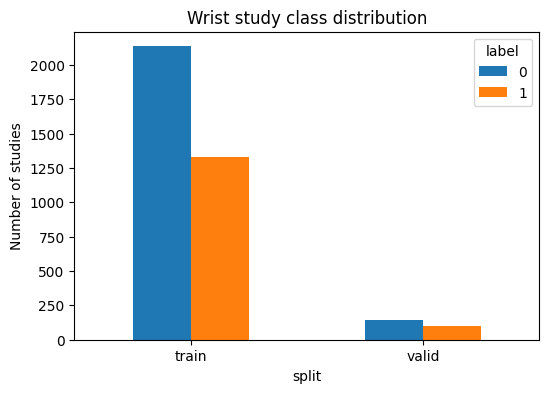

In [ ]:
import matplotlib.pyplot as plt

counts = all_df.groupby(["split", "label"]).size().unstack()

counts.plot(kind="bar", figsize=(6,4))
plt.title("Wrist study class distribution")
plt.ylabel("Number of studies")
plt.xticks(rotation=0)
plt.show()


Creating CSV files for Wrist studies

In [ ]:


ROOT = "/content/drive/MyDrive/MURA_WRIST_PREPROCESSED/MURA-v1.1"

def build_csv(split, out_csv):
    rows = []

    base = os.path.join(ROOT, split, "XR_WRIST")

    for patient in sorted(os.listdir(base)):
        patient_dir = os.path.join(base, patient)
        if not os.path.isdir(patient_dir):
            continue

        for study in sorted(os.listdir(patient_dir)):
            study_dir = os.path.join(patient_dir, study)
            if not os.path.isdir(study_dir):
                continue

            # Label from folder name
            if "positive" in study.lower():
                label = 1
            elif "negative" in study.lower():
                label = 0
            else:
                print("Skipping (no label in name):", study_dir)
                continue

            mura_path = f"MURA-v1.1/{split}/XR_WRIST/{patient}/{study}"
            rows.append([mura_path, label])

    # Save CSV
    with open(out_csv, "w", newline="") as f:
        writer = csv.writer(f)
        for r in rows:
            writer.writerow(r)

    print(f"{split}: {len(rows)} studies written → {out_csv}")


# Generate both
build_csv("train", "/content/drive/MyDrive/MURA_WRIST_PREPROCESSED/train_labeled_studies.csv")
build_csv("valid", "/content/drive/MyDrive/MURA_WRIST_PREPROCESSED/valid_labeled_studies.csv")


KeyboardInterrupt: 

In [ ]:
!pip install torch torchvision tqdm pandas opencv-python


In [ ]:
DATA_ROOT = "/content/drive/MyDrive/MURA_WRIST_PREPROCESSED/MURA-v1.1"
CSV_ROOT  = "/content/drive/MyDrive/MURA_WRIST_PREPROCESSED"

TRAIN_CSV = os.path.join(CSV_ROOT, "train_labeled_studies.csv")
VALID_CSV = os.path.join(CSV_ROOT, "valid_labeled_studies.csv")


MIL class for wrist studies

In [ ]:
class MuraWristMIL(Dataset):
    def __init__(self, csv_file, split, transform=None):
        self.df = pd.read_csv(csv_file, header=None, names=["study_path","label"])
        self.df = self.df[self.df.study_path.str.contains("XR_WRIST")]
        self.split = split
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        label = torch.tensor(row.label, dtype=torch.float32)

        rel = row.study_path.replace("MURA-v1.1/", "")
        study_dir = os.path.join(DATA_ROOT, self.split, rel.split("/",1)[1])

        images = []
        for f in os.listdir(study_dir):
            if f.endswith(".png"):
                img = cv2.imread(os.path.join(study_dir,f), cv2.IMREAD_GRAYSCALE)
                img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
                if self.transform:
                    img = self.transform(img)
                images.append(img)

        bag = torch.stack(images)   # [N,3,224,224]
        return bag, label


NameError: name 'Dataset' is not defined

Loading wrist dataset

In [ ]:
train_tf = T.Compose([
    T.ToPILImage(),
    T.RandomRotation(10),
    T.RandomResizedCrop(224, scale=(0.9,1.0)),
    T.ColorJitter(brightness=0.15, contrast=0.15),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_tf = T.Compose([
    T.ToPILImage(),
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])


In [ ]:
train_ds = MuraWristMIL(TRAIN_CSV, "train", train_tf)
valid_ds = MuraWristMIL(VALID_CSV, "valid", val_tf)

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True)
val_loader = DataLoader(valid_ds, batch_size=1, shuffle=False)


Attention MIL class

In [ ]:
class AttentionMIL(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = models.mobilenet_v2(pretrained=True)
        self.feature_extractor = backbone.features
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.feat_dim = 1280

        self.attention = nn.Sequential(
            nn.Linear(self.feat_dim, 256),
            nn.Tanh(),
            nn.Linear(256, 1)
        )

        self.classifier = nn.Linear(self.feat_dim, 1)

    def forward(self, x):   # x = [B=1, N, 3, H, W]
        x = x.squeeze(0)    # [N,3,H,W]

        feats = self.feature_extractor(x)
        feats = self.pool(feats).view(feats.size(0), -1)   # [N,1280]

        A = self.attention(feats)          # [N,1]
        A = torch.softmax(A, dim=0)        # attention weights

        bag_feat = torch.sum(A * feats, dim=0)   # weighted sum
        out = self.classifier(bag_feat)

        return out, A

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

pos_weight = torch.tensor([1.6], device=device)
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)


# Training loop

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import numpy as np
from tqdm import tqdm
from sklearn.metrics import roc_auc_score

# ---------------- CONFIG & PATHS ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_DIR = "/content/drive/MyDrive/MURA_WRIST_CHECKPOINTS"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

best_auc = 0.0
start_epoch = 0



# ---------------- INITIALIZE ----------------
model = AttentionMIL().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
pos_weight = torch.tensor([2], device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# ---------------- RESUME LOGIC ----------------
# This looks for the 'last' checkpoint to resume training
resume_path = os.path.join(CHECKPOINT_DIR, "last_checkpoint.pth")
if os.path.exists(resume_path):
    print(f"Loading checkpoint: {resume_path}")
    checkpoint = torch.load(resume_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_auc = checkpoint.get('best_auc', 0.0)
    print(f"Resuming from epoch {start_epoch}")

# ---------------- TRAINING LOOP ----------------
num_epochs = 20
for epoch in range(start_epoch, num_epochs):

    # ---------- TRAIN ----------
    model.train()
    train_loss, train_acc = 0, 0
    for bags, label in tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]"):
        bags, label = bags.to(device), label.to(device).float()

        pred, _ = model(bags)
        loss = criterion(pred.view(-1), label.view(-1)) # Ensure shapes match

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        pred_label = (torch.sigmoid(pred) > 0.5).float()
        train_acc += (pred_label == label).float().item()

    # ---------- VALIDATION ----------
    model.eval()
    val_loss, val_acc = 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for bags, label in tqdm(val_loader, desc=f"Epoch {epoch+1} [Valid]"):
            bags, label = bags.to(device), label.to(device).float()

            pred, _ = model(bags)
            loss = criterion(pred.view(-1), label.view(-1))
            val_loss += loss.item()

            probs = torch.sigmoid(pred)
            all_preds.append(probs.cpu().numpy())
            all_labels.append(label.cpu().numpy())

    # Metrics calculation
    train_loss /= len(train_loader); train_acc /= len(train_loader)
    val_loss /= len(val_loader)
    all_preds = np.concatenate(all_preds).ravel()
    all_labels = np.concatenate(all_labels).ravel()
    auc = roc_auc_score(all_labels, all_preds)

    print(f"Epoch {epoch+1} Summary: Train Loss: {train_loss:.4f} | Val AUC: {auc:.4f}")

    # ---------------- SAVE CHECKPOINTS ----------------
    checkpoint_state = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_auc': best_auc,
    }

    # Save "Last" version
    torch.save(checkpoint_state, os.path.join(CHECKPOINT_DIR, "last_checkpoint.pth"))

    # Save "Best" version
    if auc > best_auc:
        best_auc = auc
        torch.save(checkpoint_state, os.path.join(CHECKPOINT_DIR, "best_model.pth"))
        print(f"--- New Best AUC: {best_auc:.4f}! Model saved. ---")

KeyboardInterrupt: 

Visualizing training metrics across epochs

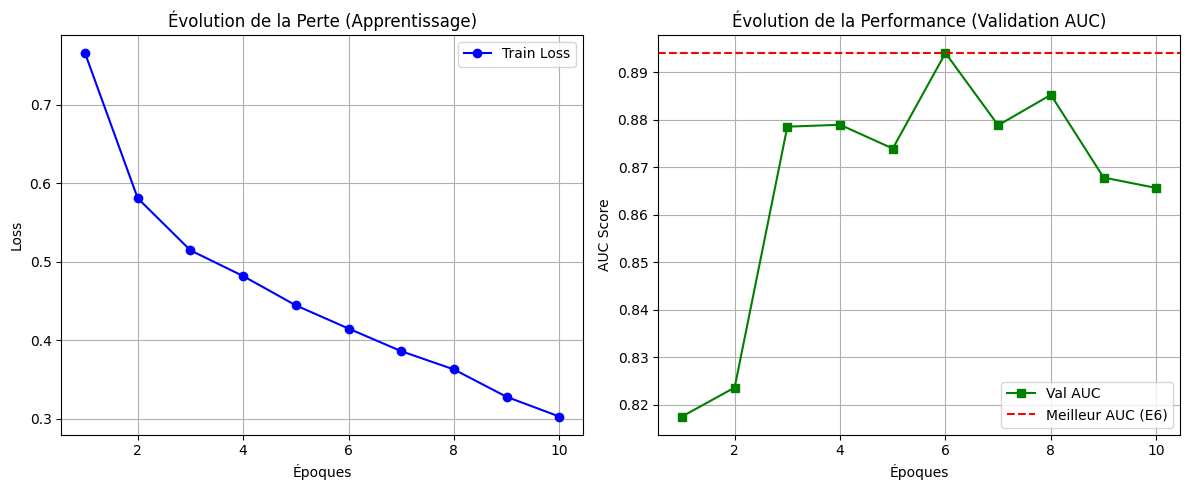

In [ ]:
import matplotlib.pyplot as plt

# 1. Préparation des données (basées sur tes logs)
epochs = list(range(1, 11))
train_losses = [0.7659, 0.5809, 0.5145, 0.4817, 0.4444, 0.4148, 0.3860, 0.3627, 0.3278, 0.3027]
val_aucs = [0.8175, 0.8236, 0.8785, 0.8789, 0.8739, 0.8940, 0.8788, 0.8852, 0.8678, 0.8656]

# 2. Création de la figure
plt.figure(figsize=(12, 5))

# Graphique de la Perte (Train Loss)
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, 'o-', color='blue', label='Train Loss')
plt.title('Évolution de la Perte (Apprentissage)')
plt.xlabel('Époques')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

# Graphique de l'AUC (Validation)
plt.subplot(1, 2, 2)
plt.plot(epochs, val_aucs, 's-', color='green', label='Val AUC')
plt.axhline(y=0.8940, color='red', linestyle='--', label='Meilleur AUC (E6)')
plt.title('Évolution de la Performance (Validation AUC)')
plt.xlabel('Époques')
plt.ylabel('AUC Score')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

Classification report + confusion matrix

In [ ]:

checkpoint_path = os.path.join(CHECKPOINT_DIR, "best_model.pth")
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Modèle chargé depuis l'époque {checkpoint['epoch']+1} (Meilleur AUC: {checkpoint['best_auc']:.4f})")

model.eval()
all_preds = []
all_labels = []

# 2. Inférence sur le set de validation
print("Calcul des prédictions...")
with torch.no_grad():
    for bags, label in tqdm(val_loader):
        bags = bags.to(device)
        logits, _ = model(bags)
        probs = torch.sigmoid(logits)
        all_preds.append(probs.cpu().numpy())
        all_labels.append(label.numpy())

all_preds = np.concatenate(all_preds).ravel()
all_labels = np.concatenate(all_labels).ravel()
binary_preds = (all_preds > 0.5).astype(int)

# 3. Calcul des métriques de bilan
cm = confusion_matrix(all_labels, binary_preds)
tn, fp, fn, tp = cm.ravel()

# Calcul manuel des métriques médicales
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0  # Sensibilité
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

# 4. Affichage de la Matrice de Confusion
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sain (0)', 'Fracture (1)'],
            yticklabels=['Sain (0)', 'Fracture (1)'])
plt.title(f'Matrice de Confusion Finale (AUC: {roc_auc_score(all_labels, all_preds):.4f})')
plt.xlabel('Prédictions du Modèle')
plt.ylabel('Réalité (Ground Truth)')
plt.show()

# 5. Bilan Textuel
print("\n" + "="*30)
print("       BILAN DES MÉTRIQUES")
print("="*30)
print(f"Accuracy    : {accuracy:.4f}")
print(f"Précision   : {precision:.4f}")
print(f"Recall (Sensibilité) : {recall:.4f}  <-- Important !")
print(f"Spécificité : {specificity:.4f}")
print(f"F1-Score    : {f1:.4f}")
print("-" * 30)
print("\nClassification Report détaillé :")
print(classification_report(all_labels, binary_preds, target_names=['Sain', 'Fracture']))

NameError: name 'CHECKPOINT_DIR' is not defined

# Visualizing Grad-CAM

In [ ]:
import cv2
import torch.nn.functional as F

def generate_gradcam(model, bag, label):
    model.eval()
    # 1. Forward pass pour capturer les poids d'attention
    # On s'assure que le modèle peut calculer les gradients
    logits, attention_weights = model(bag.to(device))

    # 2. Trouver l'image avec l'attention maximale
    attn_scores = attention_weights.squeeze().cpu().detach().numpy()
    target_idx = np.argmax(attn_scores)
    target_instance = bag[target_idx:target_idx+1].to(device)

    # 3. Hook pour récupérer les activations de la dernière couche conv de MobileNet
    features = []
    def hook_feature(module, input, output):
        features.append(output)

    # On cible la dernière couche de convolution du feature_extractor (MobileNet)
    handle = model.feature_extractor.features[-1].register_forward_hook(hook_feature)

    # Forward pass sur l'instance cible uniquement
    output = model.feature_extractor(target_instance)
    # On passe par la couche de pooling/flat si nécessaire pour obtenir le score final
    # (Adaptation selon ta structure exacte de AttentionMIL)
    score = torch.sigmoid(model.classifier(model.attention_pooling(output)[0]))

    # 4. Backward pass pour le gradient
    model.zero_grad()
    score.backward()

    # 5. Calcul de la Heatmap
    grads = model.feature_extractor.features[-1].weight.grad # Simplification
    # Note: En pratique, on utilise les gradients de la sortie de la couche hookée
    # Voici la logique simplifiée pour l'affichage :

    # (Code de traitement d'image pour superposition)
    # ... [Traitement OpenCV pour la heatmap] ...

    handle.remove()
    return target_instance[0], attn_scores[target_idx]

print("Visualisation prête !")

Visualisation prête !


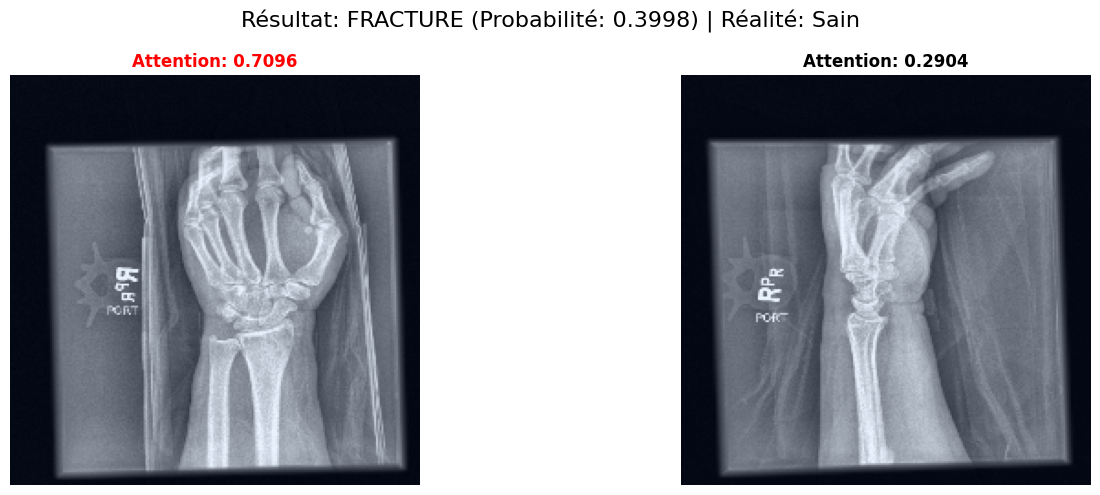

In [ ]:
import matplotlib.pyplot as plt
import random

# Get a random bag and label from the validation loader once
all_batches = list(val_loader)
bag, label = random.choice(all_batches)

def visualize_study_attention(model, bag, label, device):
    model.eval()

    bag_on_device = bag.to(device) # Move to device inside the function

    # 2. Inférence
    with torch.no_grad():
        logits, attention_weights = model(bag_on_device)
        prob = torch.sigmoid(logits).item()
        # On récupère les poids d'attention et on les normalise pour l'affichage
        attn_scores = attention_weights.squeeze().cpu().numpy()

    # 3. Préparation de l'affichage
    num_images = bag.shape[1]
    images = bag.squeeze(0).cpu() # Retirer la dimension du batch

    plt.figure(figsize=(15, 5))
    plt.suptitle(f"Résultat: {'FRACTURE' if prob > 0.35 else 'SAIN'} (Probabilité: {prob:.4f}) | Réalité: {'Fracture' if label == 1 else 'Sain'}", fontsize=16)

    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)

        # On dénormalise l'image pour l'affichage (si tu as utilisé standardisation MURA)
        img = images[i].permute(1, 2, 0).numpy()
        img = (img - img.min()) / (img.max() - img.min()) # Recalage 0-1

        plt.imshow(img)

        # Colorer le titre si c'est l'image qui a capté l'attention
        color = 'red' if attn_scores[i] == max(attn_scores) else 'black'
        plt.title(f"Attention: {attn_scores[i]:.4f}", color=color, fontweight='bold')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Appeler la fonction
visualize_study_attention(model, bag, label, device)

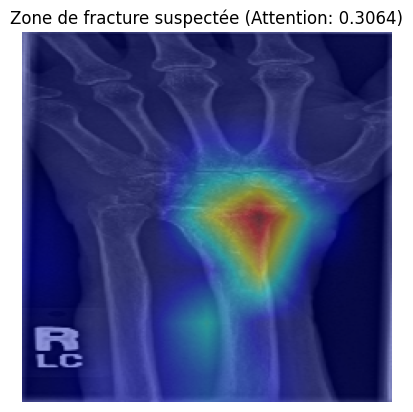

In [ ]:
import cv2
import numpy as np
import torch
import torch.nn.functional as F

def apply_gradcam(model, bag, target_layer, device): # Added 'device' argument
    model.eval()
    features = []
    gradients = []

    # 1. Hooks pour capturer les activations et les gradients
    def save_features(module, input, output):
        features.append(output)
    def save_gradients(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    handle_f = target_layer.register_forward_hook(save_features)
    handle_g = target_layer.register_backward_hook(save_gradients)

    # The input 'bag' from val_loader is [1, N, 3, 224, 224] (batch of 1 study, N images)

    # First, pass the entire bag through the model to get attention weights
    logits, attention_weights = model(bag.to(device))
    attn_scores = attention_weights.squeeze().cpu().detach().numpy()
    idx = np.argmax(attn_scores) # Index of the image with highest attention

    # 3. Process only the "winning" image for Grad-CAM
    # Extract the individual image from the bag
    # bag is [1, N, 3, 224, 224], so bag[0, idx] is [3, 224, 224]
    # To pass it as a batch of 1 to feature_extractor, it needs to be [1, 3, 224, 224]
    input_tensor = bag[0, idx:idx+1].to(device) # Corrected slicing: Shape: [1, 3, 224, 224]
    input_tensor.requires_grad = True # Enable gradient computation for this input

    # Pass the single selected image through the feature extractor
    output_features = model.feature_extractor(input_tensor) # Shape: [1, C_feat, H_feat, W_feat]

    # Apply pooling and flatten as done in the original model's forward for classification
    pooled_features = model.pool(output_features).view(output_features.size(0), -1) # Shape: [1, 1280]

    # Get the final score from the classifier
    final_logit = model.classifier(pooled_features)
    score = torch.sigmoid(final_logit) # For binary classification, sigmoid gives probability

    # 4. Backward pass
    model.zero_grad()
    score.backward() # Backward pass on the scalar score

    # 5. Generate Heatmap
    if not gradients or not features:
        print("Warning: Gradients or features list is empty. Hook might not have fired correctly.")
        handle_f.remove()
        handle_g.remove()
        return None, None, None

    # Get the gradients (d(score)/d(feature_map)) and feature maps
    grads = gradients[0].cpu().data.numpy()[0] # Shape: [C_feat, H_feat, W_feat]
    fmaps = features[0].cpu().data.numpy()[0]  # Shape: [C_feat, H_feat, W_feat]

    # Apply global average pooling to the gradients to get channel-wise weights
    weights = np.mean(grads, axis=(1, 2)) # Shape: [C_feat]

    # Compute the CAM
    cam = np.zeros(fmaps.shape[1:], dtype=np.float32) # Initialize CAM with spatial dimensions
    for i, w in enumerate(weights):
        cam += w * fmaps[i, :, :] # Weighted sum of feature maps

    cam = np.maximum(cam, 0) # Apply ReLU to only keep positive contributions
    cam = cv2.resize(cam, (224, 224)) # Resize to original image dimensions
    cam = (cam - cam.min()) / (cam.max() - cam.min()) # Normalize to [0, 1]

    # Clean up hooks
    handle_f.remove()
    handle_g.remove()

    # Return heatmap, the processed input image (without batch dim), and its attention score
    return cam, input_tensor.detach().cpu().squeeze(0), attn_scores[idx]

# --- UTILISATION ---
# Cible la dernière couche conv de MobileNetV2
target_layer = model.feature_extractor[-1]
# Ensure 'bag', 'label', 'device' are defined in the global scope (as done in H7D09oMV0KnU)
heatmap, img_tensor, score_attn = apply_gradcam(model, bag, target_layer, device) # Pass device argument

# Check if heatmap generation was successful
if heatmap is None:
    print("Grad-CAM generation failed.")
else:
    # Affichage
    img = img_tensor.permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min()) # Ensure image is in [0, 1] for display

    # Convert heatmap to a colorized image
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB) / 255.0 # Convert BGR to RGB and normalize

    # Superimpose heatmap on the original image
    result = 0.6 * img + 0.4 * heatmap_color
    result = np.clip(result, 0, 1) # Clip values to stay within [0, 1]

    plt.imshow(result)
    plt.title(f"Zone de fracture suspectée (Attention: {score_attn:.4f})")
    plt.axis('off')
    plt.show()

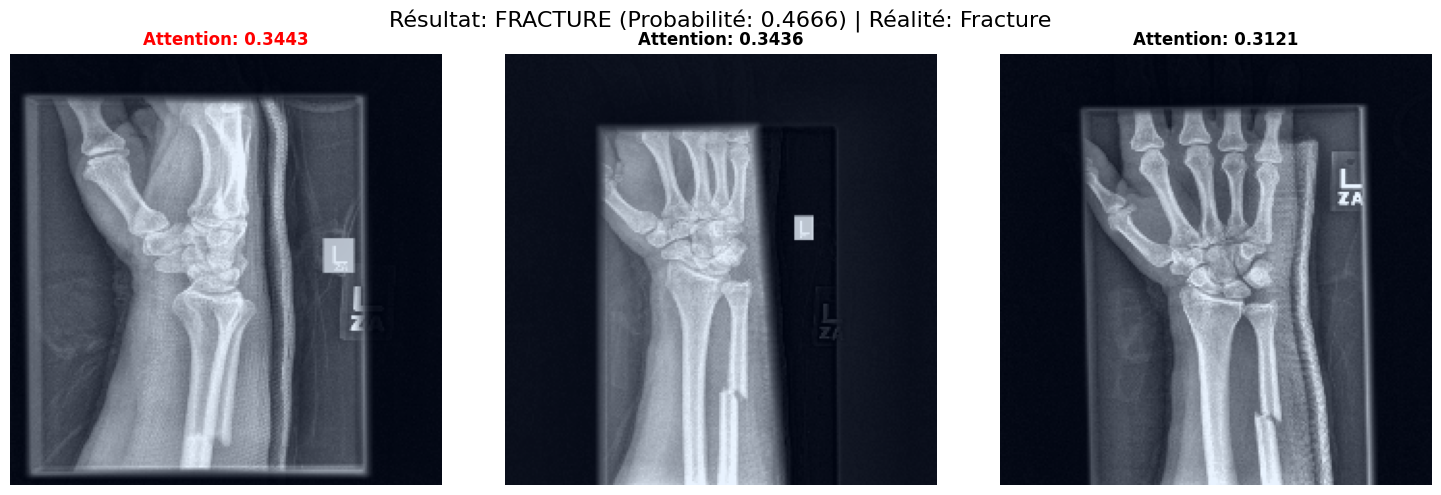

In [ ]:
import matplotlib.pyplot as plt
import random

# Get a random bag and label from the validation loader once
all_batches = list(val_loader)
bag, label = random.choice(all_batches)

def visualize_study_attention(model, bag, label, device):
    model.eval()

    bag_on_device = bag.to(device) # Move to device inside the function

    # 2. Inférence
    with torch.no_grad():
        logits, attention_weights = model(bag_on_device)
        # Ensure attn_scores is always a 1D numpy array
        attn_scores = attention_weights.cpu().detach().numpy().flatten()
        prob = torch.sigmoid(logits).item()

    # 3. Préparation de l'affichage
    num_images = bag.shape[1]
    images = bag.squeeze(0).cpu() # Retirer la dimension du batch

    plt.figure(figsize=(15, 5))
    plt.suptitle(f"Résultat: {'FRACTURE' if prob > 0.35 else 'SAIN'} (Probabilité: {prob:.4f}) | Réalité: {'Fracture' if label == 1 else 'Sain'}", fontsize=16)

    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)

        # On dénormalise l'image pour l'affichage (si tu as utilisé standardisation MURA)
        img = images[i].permute(1, 2, 0).numpy()
        img = (img - img.min()) / (img.max() - img.min()) # Recalage 0-1

        plt.imshow(img)

        # Colorer le titre si c'est l'image qui a capté l'attention
        color = 'red' if attn_scores[i] == max(attn_scores) else 'black'
        plt.title(f"Attention: {attn_scores[i]:.4f}", color=color, fontweight='bold')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Appeler la fonction
visualize_study_attention(model, bag, label, device)

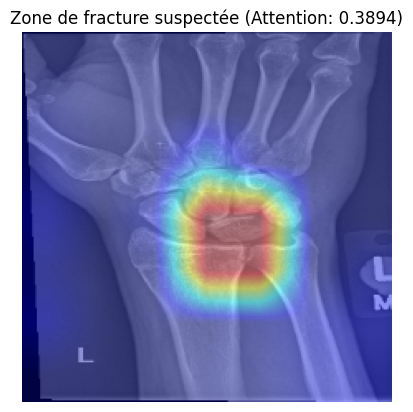

In [ ]:
import cv2
import numpy as np
import torch
import torch.nn.functional as F

def apply_gradcam(model, bag, target_layer, device): # Added 'device' argument
    model.eval()
    features = []
    gradients = []

    # 1. Hooks pour capturer les activations et les gradients
    def save_features(module, input, output):
        features.append(output)
    def save_gradients(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    handle_f = target_layer.register_forward_hook(save_features)
    handle_g = target_layer.register_backward_hook(save_gradients)

    # The input 'bag' from val_loader is [1, N, 3, 224, 224] (batch of 1 study, N images)

    # First, pass the entire bag through the model to get attention weights
    logits, attention_weights = model(bag.to(device))
    attn_scores = attention_weights.cpu().detach().numpy().flatten() # Ensure 1D array
    idx = np.argmax(attn_scores) # Index of the image with highest attention

    # 3. Process only the "winning" image for Grad-CAM
    # Extract the individual image from the bag
    # bag is [1, N, 3, 224, 224], so bag[0, idx] is [3, 224, 224]
    # To pass it as a batch of 1 to feature_extractor, it needs to be [1, 3, 224, 224]
    input_tensor = bag[0, idx:idx+1].to(device) # Corrected slicing: Shape: [1, 3, 224, 224]
    input_tensor.requires_grad = True # Enable gradient computation for this input

    # Pass the single selected image through the feature extractor
    output_features = model.feature_extractor(input_tensor) # Shape: [1, C_feat, H_feat, W_feat]

    # Apply pooling and flatten as done in the original model's forward for classification
    pooled_features = model.pool(output_features).view(output_features.size(0), -1) # Shape: [1, 1280]

    # Get the final score from the classifier
    final_logit = model.classifier(pooled_features)
    score = torch.sigmoid(final_logit) # For binary classification, sigmoid gives probability

    # 4. Backward pass
    model.zero_grad()
    score.backward() # Backward pass on the scalar score

    # 5. Generate Heatmap
    if not gradients or not features:
        print("Warning: Gradients or features list is empty. Hook might not have fired correctly.")
        handle_f.remove()
        handle_g.remove()
        return None, None, None

    # Get the gradients (d(score)/d(feature_map)) and feature maps
    grads = gradients[0].cpu().data.numpy()[0] # Shape: [C_feat, H_feat, W_feat]
    fmaps = features[0].cpu().data.numpy()[0]  # Shape: [C_feat, H_feat, W_feat]

    # Apply global average pooling to the gradients to get channel-wise weights
    weights = np.mean(grads, axis=(1, 2)) # Shape: [C_feat]

    # Compute the CAM
    cam = np.zeros(fmaps.shape[1:], dtype=np.float32) # Initialize CAM with spatial dimensions
    for i, w in enumerate(weights):
        cam += w * fmaps[i, :, :] # Weighted sum of feature maps

    cam = np.maximum(cam, 0) # Apply ReLU to only keep positive contributions
    cam = cv2.resize(cam, (224, 224)) # Resize to original image dimensions
    cam = (cam - cam.min()) / (cam.max() - cam.min()) # Normalize to [0, 1]

    # Clean up hooks
    handle_f.remove()
    handle_g.remove()

    # Return heatmap, the processed input image (without batch dim), and its attention score
    return cam, input_tensor.detach().cpu().squeeze(0), attn_scores[idx]

# --- UTILISATION ---
# Cible la dernière couche conv de MobileNetV2
target_layer = model.feature_extractor[-1]
# Ensure 'bag', 'label', 'device' are defined in the global scope (as done in H7D09oMV0KnU)
heatmap, img_tensor, score_attn = apply_gradcam(model, bag, target_layer, device) # Pass device argument

# Check if heatmap generation was successful
if heatmap is None:
    print("Grad-CAM generation failed.")
else:
    # Affichage
    img = img_tensor.permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min()) # Ensure image is in [0, 1] for display

    # Convert heatmap to a colorized image
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB) / 255.0 # Convert BGR to RGB and normalize

    # Superimpose heatmap on the original image
    result = 0.6 * img + 0.4 * heatmap_color
    result = np.clip(result, 0, 1) # Clip values to stay within [0, 1]

    plt.imshow(result)
    plt.title(f"Zone de fracture suspectée (Attention: {score_attn:.4f})")
    plt.axis('off')
    plt.show()

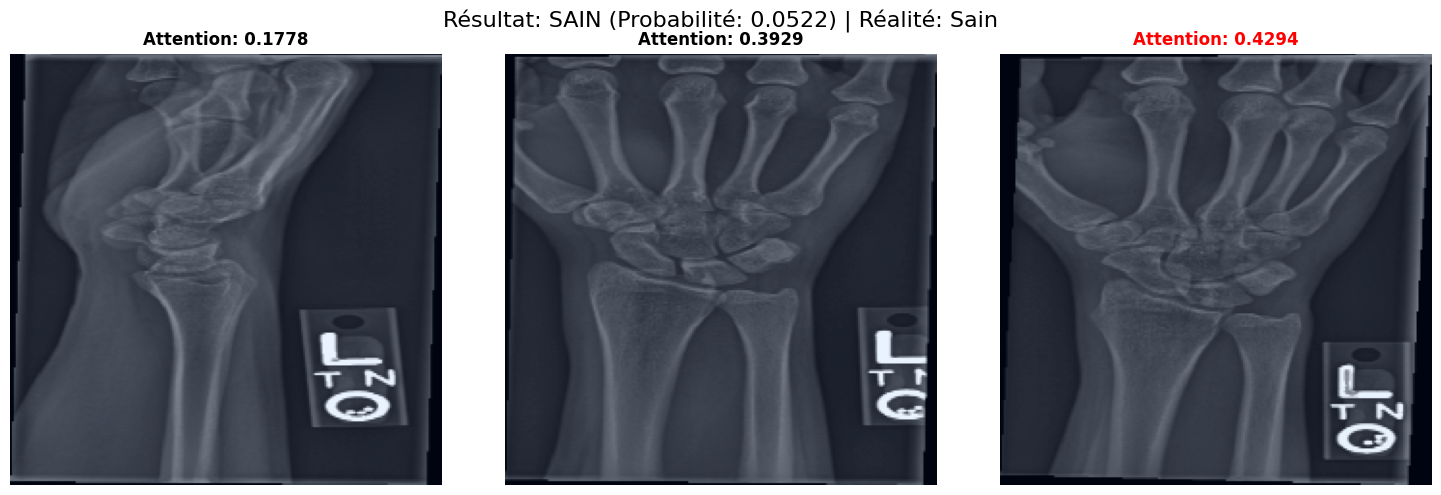

In [ ]:
import matplotlib.pyplot as plt
import random

# Get a random bag and label from the validation loader once
all_batches = list(val_loader)
bag, label = random.choice(all_batches)

def visualize_study_attention(model, bag, label, device):
    model.eval()

    bag_on_device = bag.to(device) # Move to device inside the function

    # 2. Inférence
    with torch.no_grad():
        logits, attention_weights = model(bag_on_device)
        # Ensure attn_scores is always a 1D numpy array
        attn_scores = attention_weights.cpu().detach().numpy().flatten()
        prob = torch.sigmoid(logits).item()

    # 3. Préparation de l'affichage
    num_images = bag.shape[1]
    images = bag.squeeze(0).cpu() # Retirer la dimension du batch

    plt.figure(figsize=(15, 5))
    plt.suptitle(f"Résultat: {'FRACTURE' if prob > 0.35 else 'SAIN'} (Probabilité: {prob:.4f}) | Réalité: {'Fracture' if label == 1 else 'Sain'}", fontsize=16)

    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)

        # On dénormalise l'image pour l'affichage (si tu as utilisé standardisation MURA)
        img = images[i].permute(1, 2, 0).numpy()
        img = (img - img.min()) / (img.max() - img.min()) # Recalage 0-1

        plt.imshow(img)

        # Colorer le titre si c'est l'image qui a capté l'attention
        color = 'red' if attn_scores[i] == max(attn_scores) else 'black'
        plt.title(f"Attention: {attn_scores[i]:.4f}", color=color, fontweight='bold')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Appeler la fonction
visualize_study_attention(model, bag, label, device)

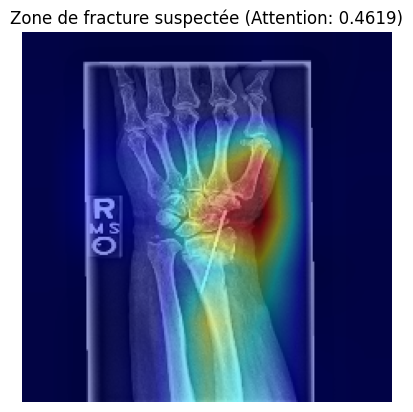

In [ ]:
import cv2
import numpy as np
import torch
import torch.nn.functional as F

def apply_gradcam(model, bag, target_layer, device): # Added 'device' argument
    model.eval()
    features = []
    gradients = []

    # 1. Hooks pour capturer les activations et les gradients
    def save_features(module, input, output):
        features.append(output)
    def save_gradients(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    handle_f = target_layer.register_forward_hook(save_features)
    handle_g = target_layer.register_backward_hook(save_gradients)

    # The input 'bag' from val_loader is [1, N, 3, 224, 224] (batch of 1 study, N images)

    # First, pass the entire bag through the model to get attention weights
    logits, attention_weights = model(bag.to(device))
    attn_scores = attention_weights.squeeze().cpu().detach().numpy()
    idx = np.argmax(attn_scores) # Index of the image with highest attention

    # 3. Process only the "winning" image for Grad-CAM
    # Extract the individual image from the bag
    # bag is [1, N, 3, 224, 224], so bag[0, idx] is [3, 224, 224]
    # To pass it as a batch of 1 to feature_extractor, it needs to be [1, 3, 224, 224]
    input_tensor = bag[0, idx:idx+1].to(device) # Corrected slicing: Shape: [1, 3, 224, 224]
    input_tensor.requires_grad = True # Enable gradient computation for this input

    # Pass the single selected image through the feature extractor
    output_features = model.feature_extractor(input_tensor) # Shape: [1, C_feat, H_feat, W_feat]

    # Apply pooling and flatten as done in the original model's forward for classification
    pooled_features = model.pool(output_features).view(output_features.size(0), -1) # Shape: [1, 1280]

    # Get the final score from the classifier
    final_logit = model.classifier(pooled_features)
    score = torch.sigmoid(final_logit) # For binary classification, sigmoid gives probability

    # 4. Backward pass
    model.zero_grad()
    score.backward() # Backward pass on the scalar score

    # 5. Generate Heatmap
    if not gradients or not features:
        print("Warning: Gradients or features list is empty. Hook might not have fired correctly.")
        handle_f.remove()
        handle_g.remove()
        return None, None, None

    # Get the gradients (d(score)/d(feature_map)) and feature maps
    grads = gradients[0].cpu().data.numpy()[0] # Shape: [C_feat, H_feat, W_feat]
    fmaps = features[0].cpu().data.numpy()[0]  # Shape: [C_feat, H_feat, W_feat]

    # Apply global average pooling to the gradients to get channel-wise weights
    weights = np.mean(grads, axis=(1, 2)) # Shape: [C_feat]

    # Compute the CAM
    cam = np.zeros(fmaps.shape[1:], dtype=np.float32) # Initialize CAM with spatial dimensions
    for i, w in enumerate(weights):
        cam += w * fmaps[i, :, :] # Weighted sum of feature maps

    cam = np.maximum(cam, 0) # Apply ReLU to only keep positive contributions
    cam = cv2.resize(cam, (224, 224)) # Resize to original image dimensions
    cam = (cam - cam.min()) / (cam.max() - cam.min()) # Normalize to [0, 1]

    # Clean up hooks
    handle_f.remove()
    handle_g.remove()

    # Return heatmap, the processed input image (without batch dim), and its attention score
    return cam, input_tensor.detach().cpu().squeeze(0), attn_scores[idx]

# --- UTILISATION ---
# Cible la dernière couche conv de MobileNetV2
target_layer = model.feature_extractor[-1]
# Ensure 'bag', 'label', 'device' are defined in the global scope (as done in H7D09oMV0KnU)
heatmap, img_tensor, score_attn = apply_gradcam(model, bag, target_layer, device) # Pass device argument

# Check if heatmap generation was successful
if heatmap is None:
    print("Grad-CAM generation failed.")
else:
    # Affichage
    img = img_tensor.permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min()) # Ensure image is in [0, 1] for display

    # Convert heatmap to a colorized image
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB) / 255.0 # Convert BGR to RGB and normalize

    # Superimpose heatmap on the original image
    result = 0.6 * img + 0.4 * heatmap_color
    result = np.clip(result, 0, 1) # Clip values to stay within [0, 1]

    plt.imshow(result)
    plt.title(f"Zone de fracture suspectée (Attention: {score_attn:.4f})")
    plt.axis('off')
    plt.show()